# Final Submission 

- model-vs-target comparison
- danceability results
includes best model

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)


In [2]:
outputs_dir = Path("outputs")
baseline_path = outputs_dir / "baseline_danceability_metrics.csv"
regularized_test_path = outputs_dir / "regularized_test_results.csv"
tree_test_path = outputs_dir / "tree_test_results.csv"

if not baseline_path.exists() or not regularized_test_path.exists():
    raise FileNotFoundError(
        "Please run baseline.ipynb and regularized_models.ipynb first so outputs/ has all comparison files."
    )

baseline_df = pd.read_csv(baseline_path)
regularized_test_df = pd.read_csv(regularized_test_path)
baseline_test = baseline_df[baseline_df["split"] == "test"].copy()

frames = [regularized_test_df, baseline_test]
if tree_test_path.exists():
    tree_test_df = pd.read_csv(tree_test_path)
    frames.append(tree_test_df)
    print(f"Including {tree_test_df['model'].nunique()} tree model(s) from {tree_test_path}")
else:
    print("tree_test_results.csv not found — run tree_models.ipynb to include RF/XGBoost in the comparison.")

all_test = pd.concat(frames, ignore_index=True)
all_test = all_test.drop_duplicates(subset=["target", "model"], keep="last")
all_test.head()

Including 2 tree model(s) from outputs/tree_test_results.csv


,target,model,split,mse,mae,r2,n_features,cv_mse,cv_mae,cv_r2
2,danceability,ridge,test,0.020519,0.114990,0.417951,13.0,NaN,NaN,NaN
3,danceability,lasso,test,0.020518,0.115003,0.417972,13.0,NaN,NaN,NaN
4,energy,mean_baseline,test,0.067875,0.215563,-0.000006,13.0,NaN,NaN,NaN
5,energy,linear_regression,test,0.017964,0.103515,0.735330,13.0,NaN,NaN,NaN
6,energy,ridge,test,0.017964,0.103516,0.735331,13.0,NaN,NaN,NaN


In [3]:
comparison_pivot = all_test.pivot(index="target", columns="model", values="r2").sort_index()
comparison_pivot


model,lasso,linear_regression,mean_baseline,random_forest,ridge,xgboost
target,,,,,,
acousticness,0.564997,0.565006,-4.717791e-06,0.658143,0.565006,0.664970
danceability,0.417972,0.417949,-8.320265e-07,0.642839,0.417951,0.663182
energy,0.735335,0.735330,-6.482152e-06,0.842731,0.735331,0.850077
loudness,0.721361,0.721361,-3.349301e-07,0.855171,0.721362,0.858608
tempo,0.068486,0.068463,-1.096647e-05,0.131657,0.068461,0.129418
valence,0.292469,0.292444,-8.285051e-05,0.437910,0.292444,0.450712


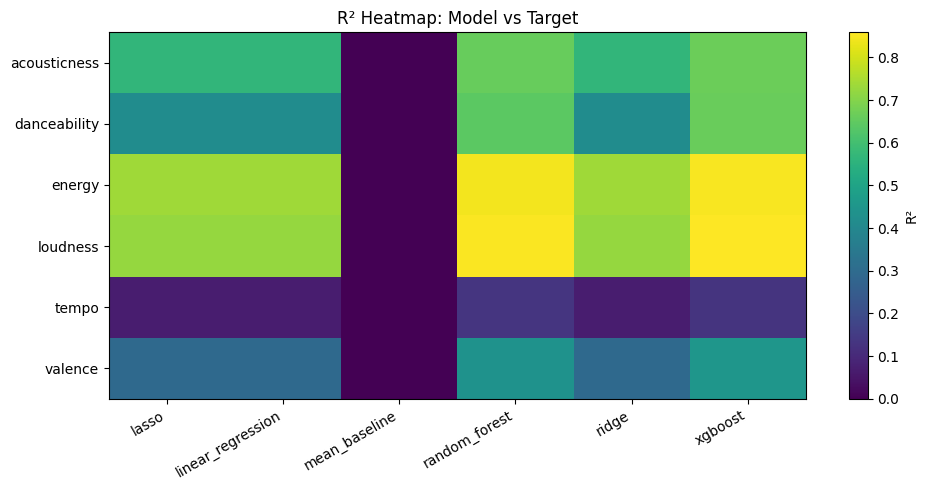

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
img = ax.imshow(comparison_pivot.values, aspect="auto")
ax.set_xticks(range(len(comparison_pivot.columns)))
ax.set_xticklabels(comparison_pivot.columns, rotation=30, ha="right")
ax.set_yticks(range(len(comparison_pivot.index)))
ax.set_yticklabels(comparison_pivot.index)
ax.set_title("R² Heatmap: Model vs Target")
fig.colorbar(img, ax=ax, label="R²")
plt.tight_layout()
plt.show()


,model,mse,mae,r2
27,xgboost,0.011874,0.084961,6.631822e-01
26,random_forest,0.012591,0.087065,6.428388e-01
3,lasso,0.020518,0.115003,4.179724e-01
2,ridge,0.020519,0.114990,4.179513e-01
24,linear_regression,0.020519,0.114989,4.179489e-01
25,mean_baseline,0.035253,0.152924,-8.320265e-07


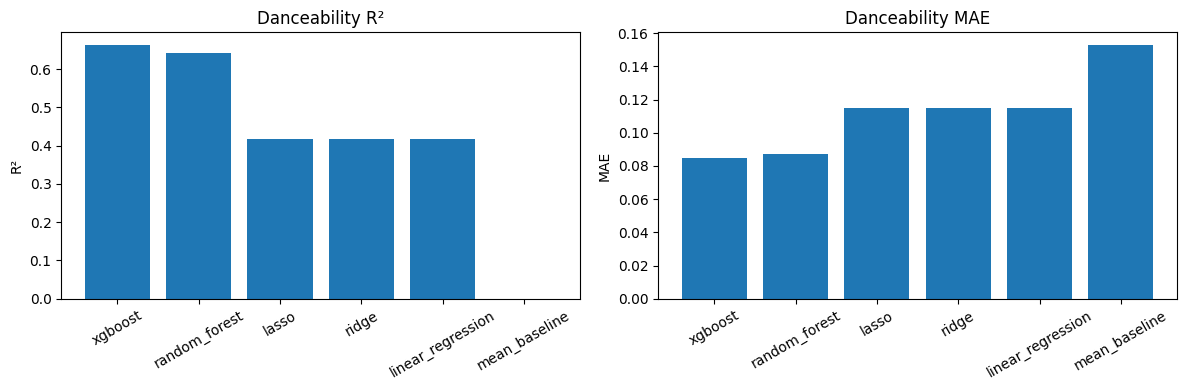

In [5]:
danceability_rows = all_test[all_test["target"] == "danceability"].sort_values("r2", ascending=False)

display(danceability_rows[["model", "mse", "mae", "r2"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(danceability_rows["model"], danceability_rows["r2"])
axes[0].set_title("Danceability R²")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(danceability_rows["model"], danceability_rows["mae"])
axes[1].set_title("Danceability MAE")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


In [6]:
best_by_target = (
    all_test.sort_values("r2", ascending=False)
    .groupby("target", as_index=False)
    .first()
    .sort_values("r2", ascending=False)
)

best_by_target


,target,model,split,mse,mae,r2,n_features,cv_mse,cv_mae,cv_r2
3,loudness,xgboost,test,6.007386,1.753105,0.858608,13.0,NaN,NaN,NaN
2,energy,xgboost,test,0.010176,0.076421,0.850077,13.0,NaN,NaN,NaN
0,acousticness,xgboost,test,0.040201,0.149082,0.664970,13.0,NaN,NaN,NaN
1,danceability,xgboost,test,0.011874,0.084961,0.663182,13.0,0.020565,0.115347,0.421151
5,valence,xgboost,test,0.036810,0.152694,0.450712,13.0,NaN,NaN,NaN
4,tempo,random_forest,test,771.735949,22.022227,0.131657,13.0,NaN,NaN,NaN


In [7]:
final_dir = Path("outputs/final")
final_dir.mkdir(parents=True, exist_ok=True)

all_test.to_csv(final_dir / "all_test_model_results.csv", index=False)
best_by_target.to_csv(final_dir / "best_model_by_target.csv", index=False)
comparison_pivot.to_csv(final_dir / "r2_comparison_pivot.csv")

print("Saved final tables to outputs/final/")


Saved final tables to outputs/final/


In [8]:
print("Final summary (for report):")
for _, row in best_by_target.iterrows():
    print(
        f"- {row['target']}: best model = {row['model']} "
        f"(R²={row['r2']:.3f}, MAE={row['mae']:.3f}, MSE={row['mse']:.4f})"
    )


Final summary (for report):
- loudness: best model = xgboost (R²=0.859, MAE=1.753, MSE=6.0074)
- energy: best model = xgboost (R²=0.850, MAE=0.076, MSE=0.0102)
- acousticness: best model = xgboost (R²=0.665, MAE=0.149, MSE=0.0402)
- danceability: best model = xgboost (R²=0.663, MAE=0.085, MSE=0.0119)
- valence: best model = xgboost (R²=0.451, MAE=0.153, MSE=0.0368)
- tempo: best model = random_forest (R²=0.132, MAE=22.022, MSE=771.7359)
